In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine, text, URL
from datetime import datetime
from pathlib import Path


In [3]:
parent_dir = Path.cwd().parent

In [4]:
load_dotenv(os.path.join(parent_dir, '.env'))

True

In [5]:
db_host = os.getenv('host')
db_port = os.getenv('port')
db_database = os.getenv('dbname')
db_user = os.getenv('user')
db_password = os.getenv('password')
db_name = 'sales'
db_schema = 'raw'

In [6]:
connection_url = URL.create(
            drivername = 'postgresql+psycopg2',
            username = db_user,
            password = db_password,
            host = db_host,
            port = int(db_port),
            database = db_database,
        )

engine = create_engine(connection_url, pool_pre_ping=True)

In [7]:
def get_data(target_year, schema, table_name):
    with engine.begin() as connection:
        query = text(f'''SELECT * 
        FROM {schema}.{table_name}
        WHERE EXTRACT(YEAR from purchase_date)={target_year}''')
        df = pd.read_sql_query(query, connection, params={'year':target_year})
        return df

In [9]:
result_df = get_data(target_year=2023, schema='raw', table_name='sales')

In [10]:
result_df.info(())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2040076 entries, 0 to 2040075
Data columns (total 11 columns):
 #   Column                 Dtype              
---  ------                 -----              
 0   sale_id                int64              
 1   client_id              int64              
 2   gender                 object             
 3   purchase_date          object             
 4   purchase_time_seconds  int64              
 5   product_id             int64              
 6   quantity               int64              
 7   price_per_item         float64            
 8   discount_per_item      float64            
 9   total_price            float64            
 10  loaded_at              datetime64[ns, UTC]
dtypes: datetime64[ns, UTC](1), float64(3), int64(5), object(2)
memory usage: 171.2+ MB


In [11]:
result_df['purchase_date'] = pd.to_datetime(result_df['purchase_date'])
result_df['purchase_month'] = result_df['purchase_date'].dt.to_period('M')

In [12]:
result_df['gross_revenue'] = result_df['quantity'] * result_df['price_per_item']
result_df['discount_amount'] = result_df['quantity'] * result_df['discount_per_item']

In [13]:
product_profile = (
    result_df
    .groupby('product_id', as_index=False)
    .agg(
        sales_count=('sale_id', 'nunique'),
        units_sold=('quantity', 'sum'),
        unique_clients=('client_id', 'nunique'),
        active_days=('purchase_date', 'nunique'),
        active_months=('purchase_month', 'nunique'),
        first_sale_date=('purchase_date', 'min'),
        last_sale_date=('purchase_date', 'max'),
        gross_revenue=('gross_revenue', 'sum'),
        discount_amount=('discount_amount', 'sum'),
        revenue=('total_price', 'sum')
    )
)

In [14]:
product_profile['avg_price_per_unit'] = product_profile['gross_revenue']/product_profile['units_sold']

product_profile['avg_units_per_sale'] = product_profile['units_sold']/product_profile['sales_count']

product_profile['avg_sale_amount'] = product_profile['revenue']/ product_profile['sales_count']

product_profile['weighted_discount_pct'] = product_profile['discount_amount']/ product_profile['gross_revenue']

product_profile['revenue_per_client'] = product_profile['revenue']/ product_profile['unique_clients']

In [15]:
product_profile = product_profile.sort_values('revenue', ascending=False).reset_index(drop=True)

product_profile.head()

,product_id,sales_count,units_sold,unique_clients,active_days,active_months,first_sale_date,last_sale_date,gross_revenue,discount_amount,revenue,avg_price_per_unit,avg_units_per_sale,avg_sale_amount,weighted_discount_pct,revenue_per_client
0,37181,60,2348,60,57,12,2023-01-06,2023-12-28,232752544.0,106245618.0,126506926.0,99128.0,39.133333,2.108449e+06,0.456475,2.108449e+06
1,30239,50,2121,50,45,12,2023-01-04,2023-12-27,206082723.0,83505638.0,122577085.0,97163.0,42.420000,2.451542e+06,0.405204,2.451542e+06
2,22406,51,2119,51,48,12,2023-01-19,2023-12-29,207884495.0,85876604.0,122007891.0,98105.0,41.549020,2.392312e+06,0.413098,2.392312e+06
3,10292,64,2202,64,61,12,2023-01-15,2023-12-28,219323604.0,98208573.0,121115031.0,99602.0,34.406250,1.892422e+06,0.447779,1.892422e+06
4,45018,61,2235,61,54,12,2023-01-11,2023-12-24,215067345.0,96745117.0,118322228.0,96227.0,36.639344,1.939709e+06,0.449836,1.939709e+06


In [16]:
assortment_summary = pd.Series({
    'Количество товаров': product_profile['product_id'].nunique(),
    'Количество продаж': product_profile['sales_count'].sum(),
    'Продано единиц': product_profile['units_sold'].sum(),
    'Выручка': product_profile['revenue'].sum(),
    'Сумма скидок': product_profile['discount_amount'].sum(),
    'Средневзвешенная скидка, %': (
        product_profile['discount_amount'].sum()
        / product_profile['gross_revenue'].sum()
        * 100
    ),
    'Медиана продаж на товар': product_profile['sales_count'].median(),
    'Медиана выручки на товар': product_profile['revenue'].median(),
    'Товаров, активных все 12 месяцев': (
        product_profile['active_months'] == 12
    ).sum()
})

assortment_summary

Количество товаров                  5.000000e+04
Количество продаж                   2.040076e+06
Продано единиц                      6.727579e+07
Выручка                             1.674710e+12
Сумма скидок                        1.676522e+12
Средневзвешенная скидка, %          5.002705e+01
Медиана продаж на товар             4.100000e+01
Медиана выручки на товар            3.179834e+07
Товаров, активных все 12 месяцев    3.241800e+04
dtype: float64

In [17]:
product_profile[
    [
        'sales_count',
        'units_sold',
        'unique_clients',
        'active_months',
        'revenue',
        'weighted_discount_pct'
    ]
].describe(
    percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).T

,count,mean,std,min,10%,25%,50%,75%,90%,95%,99%,max
sales_count,50000.0,4.080152e+01,6.385470e+00,17.000000,3.300000e+01,3.600000e+01,4.100000e+01,4.500000e+01,4.900000e+01,5.200000e+01,5.600000e+01,7.100000e+01
units_sold,50000.0,1.345516e+03,2.595722e+02,404.000000,1.021000e+03,1.165000e+03,1.335000e+03,1.515000e+03,1.684000e+03,1.788000e+03,2.003000e+03,2.714000e+03
unique_clients,50000.0,4.080058e+01,6.385028e+00,17.000000,3.300000e+01,3.600000e+01,4.100000e+01,4.500000e+01,4.900000e+01,5.200000e+01,5.600000e+01,7.100000e+01
active_months,50000.0,1.157564e+01,6.392549e-01,7.000000,1.100000e+01,1.100000e+01,1.200000e+01,1.200000e+01,1.200000e+01,1.200000e+01,1.200000e+01,1.200000e+01
revenue,50000.0,3.349419e+07,2.121745e+07,654.000000,6.375688e+06,1.577674e+07,3.179834e+07,4.869585e+07,6.250944e+07,7.071601e+07,8.473743e+07,1.265069e+08
weighted_discount_pct,50000.0,5.002678e-01,5.623279e-02,0.274092,4.277600e-01,4.626483e-01,5.004781e-01,5.383353e-01,5.724119e-01,5.926688e-01,6.297693e-01,7.057496e-01


In [18]:
abc_profile = product_profile.sort_values('revenue', ascending=False).reset_index(drop=True).copy()

In [19]:
total_revenue = abc_profile['revenue'].sum()
total_revenue

np.float64(1674709703821.0)

In [20]:
abc_profile['revenue_share'] = abc_profile['revenue']/total_revenue

In [21]:
abc_profile['cumulative_revenue_share'] = abc_profile['revenue_share'].cumsum()

In [22]:
abc_profile['abc_class'] = np.select([abc_profile['cumulative_revenue_share']<=0.80,
                                      abc_profile['cumulative_revenue_share']<0.95],
                                      ['A', 'B'],
                                      default='C')

abc_profile.head()

,product_id,sales_count,units_sold,unique_clients,active_days,active_months,first_sale_date,last_sale_date,gross_revenue,discount_amount,revenue,avg_price_per_unit,avg_units_per_sale,avg_sale_amount,weighted_discount_pct,revenue_per_client,revenue_share,cumulative_revenue_share,abc_class
0,37181,60,2348,60,57,12,2023-01-06,2023-12-28,232752544.0,106245618.0,126506926.0,99128.0,39.133333,2.108449e+06,0.456475,2.108449e+06,0.000076,0.000076,A
1,30239,50,2121,50,45,12,2023-01-04,2023-12-27,206082723.0,83505638.0,122577085.0,97163.0,42.420000,2.451542e+06,0.405204,2.451542e+06,0.000073,0.000149,A
2,22406,51,2119,51,48,12,2023-01-19,2023-12-29,207884495.0,85876604.0,122007891.0,98105.0,41.549020,2.392312e+06,0.413098,2.392312e+06,0.000073,0.000222,A
3,10292,64,2202,64,61,12,2023-01-15,2023-12-28,219323604.0,98208573.0,121115031.0,99602.0,34.406250,1.892422e+06,0.447779,1.892422e+06,0.000072,0.000294,A
4,45018,61,2235,61,54,12,2023-01-11,2023-12-24,215067345.0,96745117.0,118322228.0,96227.0,36.639344,1.939709e+06,0.449836,1.939709e+06,0.000071,0.000365,A


In [23]:
abc_summary = abc_profile.groupby('abc_class', as_index=False).agg(
        products=('product_id', 'nunique'),
        sales_count=('sales_count', 'sum'),
        units_sold=('units_sold', 'sum'),
        revenue=('revenue', 'sum'))

In [24]:
abc_summary['products_pct'] = abc_summary['products']/ abc_profile['product_id'].nunique()* 100


In [25]:
abc_summary['revenue_pct'] = abc_summary['revenue']/ total_revenue* 100

abc_summary = abc_summary[[
        'abc_class',
        'products',
        'products_pct',
        'sales_count',
        'units_sold',
        'revenue',
        'revenue_pct'
    ]]

abc_summary

,abc_class,products,products_pct,sales_count,units_sold,revenue,revenue_pct
0,A,26996,53.992,1125930,37513389,1.339758e+12,79.999439
1,B,11509,23.018,457283,14878224,2.512082e+11,15.000103
2,C,11495,22.990,456863,14884173,8.374317e+10,5.000459


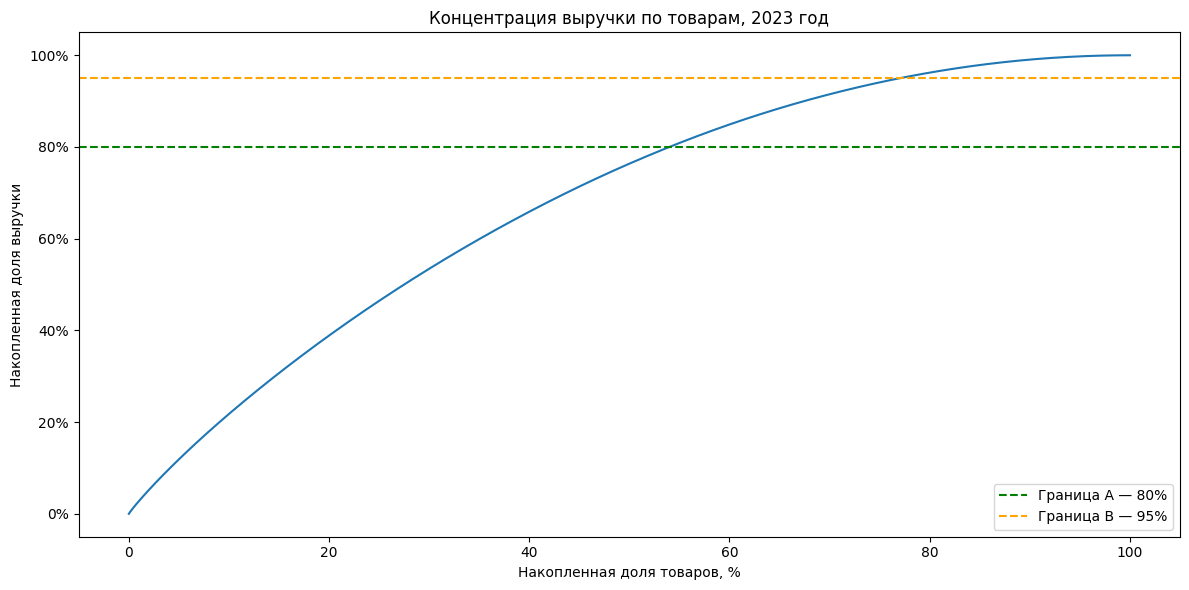

In [26]:
abc_profile['product_rank_pct'] = (abc_profile.index + 1)/ len(abc_profile)* 100


fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(data=abc_profile,x='product_rank_pct',y='cumulative_revenue_share',ax=ax)

ax.axhline(0.80, color='green', linestyle='--', label='Граница A — 80%')
ax.axhline(0.95, color='orange', linestyle='--', label='Граница B — 95%')

ax.set(
    title='Концентрация выручки по товарам, 2023 год',
    xlabel='Накопленная доля товаров, %',
    ylabel='Накопленная доля выручки'
)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'{value:.0%}'))

ax.legend()
plt.tight_layout()
plt.show()

### Вывод по ABC-анализу

В 2023 году концентрация выручки по товарам оказалась относительно низкой.
Для формирования 80% выручки потребовалось 53,99% ассортиментных позиций,
тогда как класс B включил 23,02%, а класс C — 22,99% товаров.

Таким образом, классический принцип Парето, при котором около 20% товаров
формируют 80% результата, для рассматриваемого ассортимента не выполняется.
Ассортимент достаточно однороден по вкладу отдельных товаров в выручку.

Принимать решение о сокращении товаров класса C только на основании
ABC-классификации нельзя. Необходимо дополнительно учитывать стабильность
спроса, клиентский охват, частоту продаж и эффективность предоставляемых скидок.

Месячный спрос по товарам

In [27]:
months_2023 = pd.period_range(
    start='2023-01',
    end='2023-12',
    freq='M'
)

monthly_demand = (
    result_df
    .groupby(
        ['product_id', 'purchase_month'],
        observed=True
    )['quantity']
    .sum()
    .unstack(fill_value=0)
    .reindex(columns=months_2023, fill_value=0)
)

monthly_demand.head()

,2023-01,2023-02,2023-03,2023-04,2023-05,2023-06,2023-07,2023-08,2023-09,2023-10,2023-11,2023-12
product_id,,,,,,,,,,,,
0,28,73,123,136,145,361,79,141,218,0,0,10
1,82,67,166,223,99,90,41,137,209,212,27,22
2,45,133,132,195,291,67,365,178,57,54,141,372
3,18,24,33,110,96,22,83,125,85,120,50,204
4,42,10,160,246,94,165,0,19,157,81,73,141


Коэффициент вариации

In [28]:
xyz_profile = pd.DataFrame({
    'avg_monthly_units': monthly_demand.mean(axis=1),
    'std_monthly_units': monthly_demand.std(axis=1, ddof=0)
}).reset_index()

xyz_profile['cv'] = (
    xyz_profile['std_monthly_units']
    / xyz_profile['avg_monthly_units']
)

xyz_profile['xyz_class_classic'] = np.select(
    [
        xyz_profile['cv'] <= 0.10,
        xyz_profile['cv'] <= 0.25
    ],
    ['X', 'Y'],
    default='Z'
)

In [29]:
xyz_profile['cv'].describe(
    percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]
)

count    50000.000000
mean         0.637929
std          0.143377
min          0.168246
10%          0.463717
25%          0.538946
50%          0.627655
75%          0.725456
90%          0.824485
max          1.478023
Name: cv, dtype: float64

In [30]:
xyz_profile['xyz_class_classic'].value_counts(
    normalize=False
).to_frame('products')

,products
xyz_class_classic,
Z,49976
Y,24


- минимальный CV — 16.82%;
- медианный CV — 62.77%;
- классических X-товаров нет;
- в Y попали только 24 товара;
- 49 976 товаров классифицированы как Z.

Адаптивные границы XYZ

In [31]:
cv_q25 = xyz_profile['cv'].quantile(0.25)
cv_q75 = xyz_profile['cv'].quantile(0.75)

print(f'Граница X: CV <= {cv_q25:.2%}')
print(f'Граница Y: {cv_q25:.2%} < CV <= {cv_q75:.2%}')
print(f'Граница Z: CV > {cv_q75:.2%}')

Граница X: CV <= 53.89%
Граница Y: 53.89% < CV <= 72.55%
Граница Z: CV > 72.55%


In [32]:
xyz_profile['xyz_class'] = np.select([xyz_profile['cv'] <= cv_q25,
                                      xyz_profile['cv'] <= cv_q75],
                                      ['X', 'Y'], default='Z')

In [33]:
xyz_summary = xyz_profile.groupby('xyz_class', as_index=False).agg(
    products=('product_id', 'nunique'),
    cv_min=('cv', 'min'),
    cv_median=('cv', 'median'),
    cv_max=('cv', 'max'),
    avg_monthly_units=('avg_monthly_units', 'mean'))


xyz_summary['products_pct'] = xyz_summary['products']/ xyz_profile['product_id'].nunique()* 100

xyz_summary

,xyz_class,products,cv_min,cv_median,cv_max,avg_monthly_units,products_pct
0,X,12500,0.168246,0.479213,0.538943,120.917747,25.0
1,Y,25000,0.538947,0.627655,0.725456,112.790683,50.0
2,Z,12500,0.725457,0.801997,1.478023,102.006127,25.0


Распределение коэффициента вариации

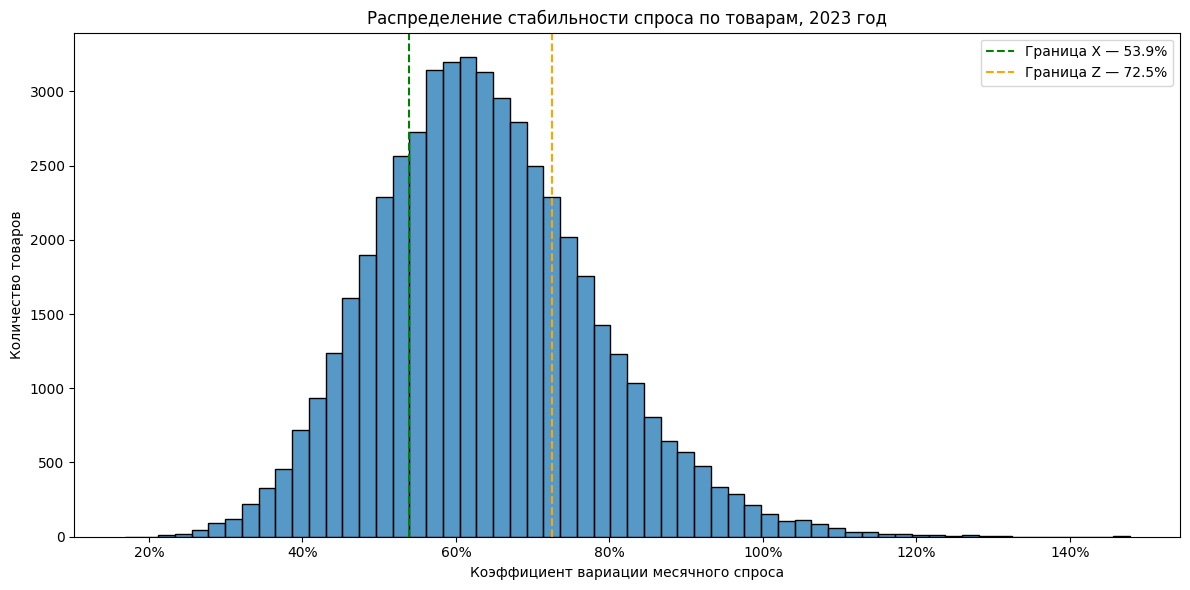

In [34]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.histplot(
    data=xyz_profile,
    x='cv',
    bins=60,
    ax=ax
)

ax.axvline(
    cv_q25,
    color='green',
    linestyle='--',
    label=f'Граница X — {cv_q25:.1%}'
)

ax.axvline(
    cv_q75,
    color='orange',
    linestyle='--',
    label=f'Граница Z — {cv_q75:.1%}'
)

ax.set(
    title='Распределение стабильности спроса по товарам, 2023 год',
    xlabel='Коэффициент вариации месячного спроса',
    ylabel='Количество товаров'
)

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f'{value:.0%}')
)

ax.legend()
plt.tight_layout()
plt.show()

### Вывод по XYZ-анализу

Классические границы XYZ не позволили содержательно сегментировать
ассортимент: 49 976 из 50 000 товаров попали в класс Z, а товары класса X
отсутствовали.

Поэтому была применена адаптивная классификация по квартилям коэффициента
вариации. Класс X включает 25% наиболее стабильных относительно остальных
товаров, класс Y — средние 50%, класс Z — 25% наиболее нестабильных.

Абсолютно стабильного спроса в ассортименте практически нет. При этом товары
класса X в среднем имеют более высокий месячный объём реализации, чем товары
класса Z: 120,9 против 102,0 единицы.

Формирование матрицы ABC–XYZ

In [35]:
abc_xyz_profile = abc_profile.merge(
    xyz_profile[
        [
            'product_id',
            'avg_monthly_units',
            'std_monthly_units',
            'cv',
            'xyz_class'
        ]
    ],
    on='product_id',
    how='left',
    validate='one_to_one'
)

abc_xyz_profile['abc_xyz_class'] = (
    abc_xyz_profile['abc_class']
    + abc_xyz_profile['xyz_class']
)

Сводка по девяти сегментам

In [36]:
abc_xyz_summary = (
    abc_xyz_profile
    .groupby('abc_xyz_class', as_index=False)
    .agg(
        products=('product_id', 'nunique'),
        sales_count=('sales_count', 'sum'),
        units_sold=('units_sold', 'sum'),
        gross_revenue=('gross_revenue', 'sum'),
        discount_amount=('discount_amount', 'sum'),
        revenue=('revenue', 'sum'),
        median_cv=('cv', 'median')
    )
)

abc_xyz_summary['products_pct'] = (
    abc_xyz_summary['products']
    / abc_xyz_profile['product_id'].nunique()
    * 100
)

abc_xyz_summary['revenue_pct'] = (
    abc_xyz_summary['revenue']
    / abc_xyz_profile['revenue'].sum()
    * 100
)

abc_xyz_summary['weighted_discount_pct'] = (
    abc_xyz_summary['discount_amount']
    / abc_xyz_summary['gross_revenue']
    * 100
)

class_order = [
    'AX', 'AY', 'AZ',
    'BX', 'BY', 'BZ',
    'CX', 'CY', 'CZ'
]

abc_xyz_summary['abc_xyz_class'] = pd.Categorical(
    abc_xyz_summary['abc_xyz_class'],
    categories=class_order,
    ordered=True
)

abc_xyz_summary = (
    abc_xyz_summary
    .sort_values('abc_xyz_class')
    .reset_index(drop=True)
)

abc_xyz_summary

,abc_xyz_class,products,sales_count,units_sold,gross_revenue,discount_amount,revenue,median_cv,products_pct,revenue_pct,weighted_discount_pct
0,AX,7166,316393,10637564,7.431227e+11,3.698092e+11,3.733135e+11,0.477721,14.332,22.291235,49.764219
1,AY,13615,568670,18968907,1.343293e+12,6.675155e+11,6.757780e+11,0.625594,27.230,40.351946,49.692453
2,AZ,6215,240867,7906918,5.761473e+11,2.854803e+11,2.906669e+11,0.797367,12.430,17.356257,49.549891
3,BX,2693,114690,3794532,1.209689e+11,6.218698e+10,5.878193e+10,0.481336,5.386,3.509978,51.407405
4,BY,5693,228160,7416519,2.553430e+11,1.308521e+11,1.244908e+11,0.631511,11.386,7.433577,51.245633
5,BZ,3123,114433,3667173,1.397303e+11,7.179492e+10,6.793540e+10,0.807164,6.246,4.056548,51.381059
6,CX,2641,112071,3705566,3.931164e+10,2.019145e+10,1.912019e+10,0.481137,5.282,1.141702,51.362532
7,CY,5692,228681,7451779,8.635930e+10,4.445513e+10,4.190417e+10,0.628354,11.384,2.502175,51.476945
8,CZ,3162,116111,3726828,4.695563e+10,2.423681e+10,2.271881e+10,0.805543,6.324,1.356582,51.616422


In [37]:
display(
    abc_xyz_summary.style.format({
        'products_pct': '{:.2f}%',
        'revenue': 'RUB {:,.0f}',
        'revenue_pct': '{:.2f}%',
        'median_cv': '{:.2%}',
        'weighted_discount_pct': '{:.2f}%'
    })
)

,abc_xyz_class,products,sales_count,units_sold,gross_revenue,discount_amount,revenue,median_cv,products_pct,revenue_pct,weighted_discount_pct
0,AX,7166,316393,10637564,743122687981.000000,369809205482.000000,"RUB 373,313,482,499",47.77%,14.33%,22.29%,49.76%
1,AY,13615,568670,18968907,1343293414980.000000,667515454635.000000,"RUB 675,777,960,345",62.56%,27.23%,40.35%,49.69%
2,AZ,6215,240867,7906918,576147255179.000000,285480337142.000000,"RUB 290,666,918,037",79.74%,12.43%,17.36%,49.55%
3,BX,2693,114690,3794532,120968914041.000000,62186979947.000000,"RUB 58,781,934,094",48.13%,5.39%,3.51%,51.41%
4,BY,5693,228160,7416519,255342950304.000000,130852111125.000000,"RUB 124,490,839,179",63.15%,11.39%,7.43%,51.25%
5,BZ,3123,114433,3667173,139730317077.000000,71794916720.000000,"RUB 67,935,400,357",80.72%,6.25%,4.06%,51.38%
6,CX,2641,112071,3705566,39311641991.000000,20191454537.000000,"RUB 19,120,187,454",48.11%,5.28%,1.14%,51.36%
7,CY,5692,228681,7451779,86359296944.000000,44455127846.000000,"RUB 41,904,169,098",62.84%,11.38%,2.50%,51.48%
8,CZ,3162,116111,3726828,46955627655.000000,24236814897.000000,"RUB 22,718,812,758",80.55%,6.32%,1.36%,51.62%


Тепловая карта доли выручки

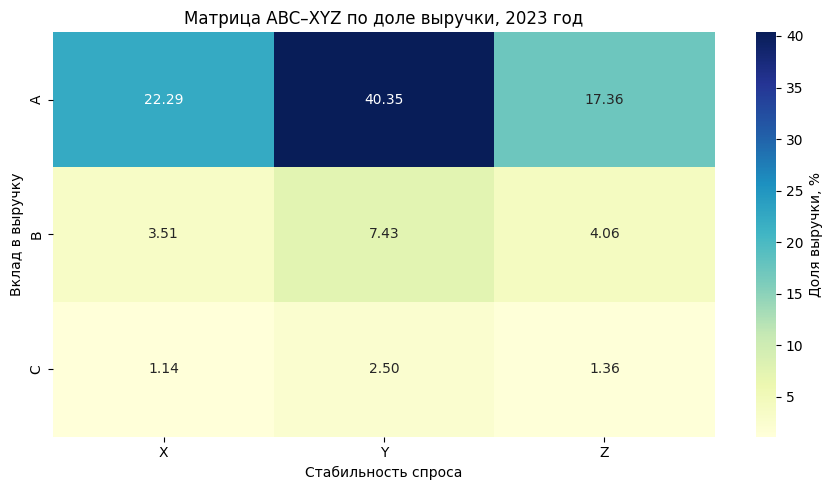

In [38]:
revenue_matrix = (
    abc_xyz_summary
    .assign(
        abc_class=lambda df: df['abc_xyz_class'].astype(str).str[0],
        xyz_class=lambda df: df['abc_xyz_class'].astype(str).str[1]
    )
    .pivot(
        index='abc_class',
        columns='xyz_class',
        values='revenue_pct'
    )
    .reindex(
        index=['A', 'B', 'C'],
        columns=['X', 'Y', 'Z']
    )
)

plt.figure(figsize=(9, 5))

sns.heatmap(
    revenue_matrix,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu',
    cbar_kws={'label': 'Доля выручки, %'}
)

plt.title('Матрица ABC–XYZ по доле выручки, 2023 год')
plt.xlabel('Стабильность спроса')
plt.ylabel('Вклад в выручку')
plt.tight_layout()
plt.show()

### Результаты ABC–XYZ-анализа

Наиболее значимым сегментом оказался AY: 13 615 товаров
(27,23% ассортимента) обеспечили 40,35% выручки. Сегмент AX
содержит 14,33% товаров и формирует ещё 22,29% выручки.
Эти две группы являются основой ассортиментной матрицы:
AX характеризуется наиболее стабильным спросом, а AY —
умеренной изменчивостью.

Сегмент AZ обеспечивает 17,36% выручки. Эти товары имеют
высокую коммерческую значимость, но относительно нестабильный
спрос, поэтому для них необходим более осторожный подход
к управлению запасами.

Классы C содержат 22,98% всех товаров, но формируют только
5% выручки. Наиболее слабым является сегмент CZ:
3 162 товара, или 6,32% ассортимента, обеспечивают лишь
1,36% выручки. Эти позиции требуют индивидуальной проверки
перед сохранением в ассортименте.

Классы XYZ сформированы по квартилям коэффициента вариации,
поскольку классические границы 10% и 25% оказались
неприменимы к исследуемым данным. Поэтому X означает
относительно наиболее стабильный спрос, Y — среднюю
стабильность, Z — относительно наиболее нестабильный спрос.

### Проверка эффективности скидок

1. Сформируем показатели по товару и месяцу

In [ ]:
result_df['purchase_date'] = pd.to_datetime(result_df['purchase_date'])
result_df['purchase_month'] = result_df['purchase_date'].dt.to_period('M')

result_df['gross_revenue'] = result_df['quantity'] * result_df['price_per_item']


result_df['discount_amount'] = result_df['quantity'] * result_df['discount_per_item']

product_monthly = result_df.groupby(['product_id', 'purchase_month'], as_index=False).agg(
        sales_count=('sale_id', 'nunique'),
        units_sold=('quantity', 'sum'),
        gross_revenue=('gross_revenue', 'sum'),
        discount_amount=('discount_amount', 'sum'),
        revenue=('total_price', 'sum')
    )


product_monthly['weighted_discount_pct'] = product_monthly['discount_amount']/ product_monthly['gross_revenue']* 100


product_monthly.head()

,product_id,purchase_month,sales_count,units_sold,gross_revenue,discount_amount,revenue,weighted_discount_pct
0,0,2023-01,1,28,1522892.0,1303204.0,219688.0,85.574289
1,0,2023-02,2,73,3970397.0,1223460.0,2746937.0,30.814551
2,0,2023-03,5,123,6689847.0,4367809.0,2322038.0,65.290118
3,0,2023-04,2,136,7396904.0,2603070.0,4793834.0,35.191345
4,0,2023-05,3,145,7886405.0,3861670.0,4024735.0,48.966164


In [40]:
product_monthly['product_median_discount'] = product_monthly.groupby('product_id')['weighted_discount_pct'].transform('median')


product_monthly['discount_level'] = np.where(product_monthly['weighted_discount_pct']> product_monthly['product_median_discount'],'high','low')

In [41]:
low_discount = (
    product_monthly[
        product_monthly['discount_level'] == 'low'
    ]
    .groupby('product_id', as_index=False)
    .agg(
        low_months=('purchase_month', 'nunique'),
        low_discount_pct=('weighted_discount_pct', 'mean'),
        low_units=('units_sold', 'mean'),
        low_sales=('sales_count', 'mean')
    )
)

high_discount = (
    product_monthly[
        product_monthly['discount_level'] == 'high'
    ]
    .groupby('product_id', as_index=False)
    .agg(
        high_months=('purchase_month', 'nunique'),
        high_discount_pct=('weighted_discount_pct', 'mean'),
        high_units=('units_sold', 'mean'),
        high_sales=('sales_count', 'mean')
    )
)

discount_response = low_discount.merge(
    high_discount,
    on='product_id',
    how='inner',
    validate='one_to_one'
)

# Оставляем товары, у которых есть хотя бы по два месяца
# в каждой сравниваемой группе
discount_response = discount_response[
    (discount_response['low_months'] >= 2)
    & (discount_response['high_months'] >= 2)
].copy()

discount_response['discount_gap_pp'] = (
    discount_response['high_discount_pct']
    - discount_response['low_discount_pct']
)

discount_response['units_uplift_pct'] = (
    discount_response['high_units']
    / discount_response['low_units']
    - 1
) * 100

discount_response['sales_uplift_pct'] = (
    discount_response['high_sales']
    / discount_response['low_sales']
    - 1
) * 100

discount_response.head()

,product_id,low_months,low_discount_pct,low_units,low_sales,high_months,high_discount_pct,high_units,high_sales,discount_gap_pp,units_uplift_pct,sales_uplift_pct
0,0,5,22.737763,131.800000,3.200000,5,66.593162,131.000000,3.400000,43.855399,-0.606980,6.250000
1,1,6,32.174267,130.166667,4.166667,6,68.596462,99.000000,3.166667,36.422195,-23.943662,-24.000000
2,2,6,32.355002,152.333333,4.833333,6,64.203352,186.000000,5.000000,31.848350,22.100656,3.448276
3,3,6,37.157267,106.500000,3.000000,6,67.695140,55.166667,2.333333,30.537873,-48.200313,-22.222222
4,4,6,32.028047,109.000000,3.000000,5,70.578833,106.800000,4.000000,38.550786,-2.018349,33.333333


In [42]:
discount_response = discount_response.merge(
    abc_xyz_profile[
        ['product_id', 'abc_class', 'xyz_class', 'abc_xyz_class']
    ],
    on='product_id',
    how='left',
    validate='one_to_one'
)

In [43]:
discount_summary = (
    discount_response
    .groupby('abc_xyz_class', as_index=False)
    .agg(
        products=('product_id', 'nunique'),
        median_discount_gap_pp=('discount_gap_pp', 'median'),
        median_units_uplift_pct=('units_uplift_pct', 'median'),
        median_sales_uplift_pct=('sales_uplift_pct', 'median'),
        positive_units_response_pct=(
            'units_uplift_pct',
            lambda x: (x > 0).mean() * 100
        )
    )
)

class_order = [
    'AX', 'AY', 'AZ',
    'BX', 'BY', 'BZ',
    'CX', 'CY', 'CZ'
]

discount_summary['abc_xyz_class'] = pd.Categorical(
    discount_summary['abc_xyz_class'],
    categories=class_order,
    ordered=True
)

discount_summary = (
    discount_summary
    .sort_values('abc_xyz_class')
    .reset_index(drop=True)
)

discount_summary.style.format({
    'median_discount_gap_pp': '{:.2f} п.п.',
    'median_units_uplift_pct': '{:+.2f}%',
    'median_sales_uplift_pct': '{:+.2f}%',
    'positive_units_response_pct': '{:.2f}%'
})

,abc_xyz_class,products,median_discount_gap_pp,median_units_uplift_pct,median_sales_uplift_pct,positive_units_response_pct
0,AX,7166,29.04 п.п.,+0.74%,+0.00%,50.78%
1,AY,13615,30.23 п.п.,-1.06%,+0.00%,48.87%
2,AZ,6215,31.23 п.п.,-2.25%,+0.00%,48.03%
3,BX,2693,29.62 п.п.,+0.71%,+0.00%,50.95%
4,BY,5693,30.42 п.п.,+0.28%,+0.00%,50.27%
5,BZ,3123,31.90 п.п.,-1.22%,+0.00%,49.09%
6,CX,2641,29.42 п.п.,+0.46%,+0.00%,50.47%
7,CY,5692,30.51 п.п.,-0.46%,+0.00%,49.47%
8,CZ,3162,31.88 п.п.,+0.95%,+0.00%,50.70%


In [44]:
discount_response[
    ['sales_uplift_pct', 'units_uplift_pct']
].describe(
    percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]
)

,sales_uplift_pct,units_uplift_pct
count,50000.000000,50000.000000
mean,4.594783,7.806065
std,33.948703,45.194120
min,-77.777778,-89.565217
10%,-33.333333,-40.072220
25%,-19.230769,-23.205128
50%,0.000000,-0.311530
75%,22.222222,29.613379
90%,48.235294,64.730476
max,287.500000,502.857143


In [45]:
(
    discount_response
    .groupby('abc_xyz_class')
    .agg(
        median_sales_uplift_pct=('sales_uplift_pct', 'median'),
        mean_sales_uplift_pct=('sales_uplift_pct', 'mean'),
        median_units_uplift_pct=('units_uplift_pct', 'median')
    )
    .round(4)
)

,median_sales_uplift_pct,mean_sales_uplift_pct,median_units_uplift_pct
abc_xyz_class,,,
AX,0.0,4.0788,0.7422
AY,0.0,4.5149,-1.0581
AZ,0.0,6.0871,-2.2453
BX,0.0,2.3958,0.7080
BY,0.0,4.3170,0.2829
BZ,0.0,5.4831,-1.2153
CX,0.0,3.3097,0.4559
CY,0.0,4.2580,-0.4631
CZ,0.0,6.3503,0.9453


### Оценка реакции спроса на увеличение скидки

Для каждого товара месяцы были разделены на периоды с относительно
высокой и низкой скидкой. Сравнение проводилось внутри одного товара,
что позволяет частично исключить влияние различий в популярности товаров.

Увеличение скидки примерно на 29–32 процентных пункта не сопровождалось
заметным ростом спроса. Медианное изменение количества проданных единиц
во всех классах ABC–XYZ находилось в диапазоне от −2,25% до +0,95%,
а доля товаров с положительной реакцией составляла около 48–51%.

Следовательно, использование массовых скидок не демонстрирует устойчивой
связи с увеличением объёма продаж. Рекомендуется отказаться от одинаковых
скидок для всего ассортимента и применять их только к отдельным товарам,
для которых положительный эффект подтверждается историческими данными
или контролируемым экспериментом.

Полученные результаты показывают статистическую связь, но не доказывают
причинное влияние скидки: на показатели также могли воздействовать
сезонность, рекламные кампании и первоначальное изменение спроса.

# Исследование ассортиментной матрицы за 2023 год

## Цель исследования

Цель исследования — оценить структуру ассортимента, определить вклад товаров в выручку, проанализировать стабильность спроса и эффективность скидок, а также сформулировать рекомендации по оптимизации ассортиментной матрицы.

## Основные результаты

### 1. Структура ассортимента

В исследуемом периоде представлено **50 000 товаров**.

По результатам ABC-анализа:

| ABC-класс | Количество товаров | Доля ассортимента | Доля выручки |
|---|---:|---:|---:|
| A | 26 996 | 53,99% | 80,00% |
| B | 11 509 | 23,02% | 15,00% |
| C | 11 495 | 22,99% | 5,00% |

Классическое правило Парето 20/80 в данных не выполняется: для формирования 80% выручки требуется около **54% ассортимента**. Следовательно, выручка распределена между товарами относительно равномерно, а массовое сокращение низкодоходных позиций может привести к неоправданному уменьшению ассортимента.

### 2. Стабильность спроса

При использовании классических границ XYZ-анализа практически все товары попадали в класс Z. Поэтому для текущего набора данных была применена адаптивная классификация по квартилям коэффициента вариации:

- **X** — 25% товаров с наиболее стабильным спросом;
- **Y** — 50% товаров со средней стабильностью спроса;
- **Z** — 25% товаров с наиболее нестабильным спросом.

Класс X в данном исследовании следует интерпретировать как относительно наиболее стабильную часть ассортимента. Даже у этих товаров спрос остаётся достаточно изменчивым.

### 3. Результаты ABC–XYZ-анализа

| Класс | Доля товаров | Доля выручки |
|---|---:|---:|
| AX | 14,33% | 22,29% |
| AY | 27,23% | 40,35% |
| AZ | 12,43% | 17,36% |
| BX | 5,39% | 3,51% |
| BY | 11,39% | 7,43% |
| BZ | 6,25% | 4,06% |
| CX | 5,28% | 1,14% |
| CY | 11,38% | 2,50% |
| CZ | 6,32% | 1,36% |

Наиболее значимым сегментом является **AY**: он включает 27,23% товаров и формирует 40,35% выручки.

Сегменты **AX, AY и AZ** совокупно формируют около 80% выручки. При этом большая часть выручки приходится на товары со средней или высокой изменчивостью спроса, что повышает требования к прогнозированию и управлению запасами.

Класс C занимает около 23% ассортимента и формирует только 5% выручки. Наиболее слабым сегментом является **CZ**: 6,32% товаров обеспечивают лишь 1,36% выручки.

### 4. Оценка эффективности скидок

Для каждого товара были сопоставлены месяцы с относительно высокой и низкой скидкой. Сравнение проводилось внутри одного товара, что позволяет частично исключить влияние различий в популярности отдельных позиций.

Разница между периодами с высокой и низкой скидкой составила около **29–32 процентных пунктов**. При этом:

- медианное изменение количества проданных единиц находилось в диапазоне от **−2,25% до +0,95%**;
- доля товаров с положительной реакцией на повышение скидки составила около **48–51%**;
- медианное изменение количества продаж практически отсутствовало.

Таким образом, значительное увеличение скидки не сопровождалось устойчивым ростом спроса. Массовое применение скидок не выглядит эффективным инструментом увеличения количества продаж.

Полученный результат показывает статистическую связь, но не доказывает причинное влияние скидки. На спрос также могли воздействовать сезонность, рекламные кампании, изменение товарных остатков и другие факторы.

## Рекомендации

### Товары AX

Товары AX обладают высокой ценностью и относительно стабильным спросом.

Рекомендуется:

- поддерживать высокий уровень доступности;
- минимизировать риск отсутствия товара;
- использовать регулярное пополнение запасов;
- избегать необоснованных массовых скидок;
- контролировать уровень скидки для сохранения потенциальной маржинальности.

### Товары AY

Сегмент AY формирует наибольшую долю выручки и является основой ассортиментной матрицы.

Рекомендуется:

- сохранять широкую представленность товаров;
- учитывать колебания спроса при планировании запасов;
- использовать прогнозирование на уровне отдельных товаров;
- применять персональные предложения вместо одинаковых скидок для всего сегмента.

### Товары AZ

Товары AZ формируют значительную долю выручки, но обладают нестабильным спросом.

Рекомендуется:

- чаще пересматривать параметры запасов;
- использовать меньшие партии пополнения;
- учитывать сезонность и периоды повышенного спроса;
- избегать формирования избыточных запасов;
- проводить точечные промоакции только после оценки исторической реакции товара.

### Товары BX и CX

Эти товары имеют относительно стабильный спрос, но обладают меньшим вкладом в выручку.

Рекомендуется:

- рассматривать их как кандидатов для точечных экспериментов;
- тестировать рекомендации сопутствующих товаров;
- объединять позиции в товарные комплекты;
- оценивать возможность увеличения средней цены или снижения скидки;
- анализировать потенциал перевода отдельных товаров в более высокий ABC-класс.

### Товары BZ, CY и CZ

Эти группы требуют индивидуального анализа. Особенно это относится к сегменту CZ, который характеризуется низким вкладом в выручку и высокой нестабильностью спроса.

Рекомендуется:

- сформировать перечень товаров для предметного аудита;
- проверить частоту и давность продаж;
- оценить стратегическую роль каждого товара;
- проверить наличие связанных и сопутствующих покупок;
- сократить закупочные партии;
- ограничить объём складских запасов;
- рассмотреть вывод отдельных позиций только после дополнительной проверки.

Принадлежность товара к классу C или CZ сама по себе не является достаточным основанием для его автоматического исключения из ассортимента.

### Управление скидками

Результаты исследования не подтверждают эффективность массового увеличения скидок.

Рекомендуется:

- отказаться от одинаковых скидок для всего ассортимента;
- сокращать скидки на товары, для которых отсутствует подтверждённая реакция спроса;
- использовать персональные предложения и товарные комплекты;
- проводить контролируемые эксперименты для оценки эффективности промоакций;
- оценивать не только рост количества продаж, но и изменение прибыли;
- предоставлять скидки только тем товарам и клиентским сегментам, где ожидаемый эффект подтверждается данными.

## Ограничения исследования

В исходных данных отсутствуют:

- себестоимость товаров;
- информация о складских остатках;
- наименования и категории товаров;
- сведения о дефиците и периодах отсутствия товара;
- данные о рекламных кампаниях;
- информация о фактической прибыли.

Поэтому в рамках исследования невозможно рассчитать реальную маржинальность, определить причины отсутствия продаж или предложить конкретные новые товарные позиции.

Рекомендации сформированы на уровне товарных сегментов. Решения о выводе отдельных товаров из ассортимента необходимо принимать после дополнительного анализа конкретных `product_id`.

## Итоговый вывод

Ассортимент маркетплейса является достаточно диверсифицированным: для формирования 80% выручки требуется около 54% товарных позиций. Поэтому массовое сокращение ассортимента не рекомендуется.

Основное внимание следует уделить обеспечению доступности товаров AX и AY, более точному управлению запасами AZ и индивидуальному аудиту товаров BZ, CY и CZ.

Значительное повышение скидок не связано с сопоставимым увеличением количества продаж. Потенциальное увеличение маржинальности следует искать в сокращении неэффективных скидок, персонализации предложений и проведении контролируемых экспериментов.

Исследование ассортиментной матрицы за 2023 год можно считать завершённым.
